In [7]:
#import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score ,precision_score ,recall_score
from sklearn.metrics import f1_score , roc_auc_score ,average_precision_score

sns.set()
%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

income_df = pd.read_csv("Housing Affordability\data\Income.csv")
housing_df = pd.read_csv("Housing Affordability\data\ShelterCosts.csv")

import warnings
# For Ignore all warnings
warnings.filterwarnings('ignore')
# For Ignore all FutureWarning messages
warnings.simplefilter(action='ignore', category=FutureWarning)

In [8]:
# Clean income data
income_clean = income_df[
    (income_df["Statistics"] == "Median income") &
    (income_df["GEO"] == "Canada") &
    (income_df["Sex"] == "Both sexes")
][["REF_DATE", "VALUE"]]

income_clean = income_clean.rename(columns={
    "REF_DATE": "year",
    "VALUE": "median_income"
})

income_clean["median_income"] = pd.to_numeric(income_clean["median_income"])


# Clean housing (shelter cost) data
housing_clean = housing_df[
    (housing_df["Household expenditures, summary-level categories"] == "Shelter") &
    (housing_df["GEO"] == "Canada") &
    (housing_df["Household type"] == "All classes")
][["REF_DATE", "VALUE"]]

housing_clean = housing_clean.rename(columns={
    "REF_DATE": "year",
    "VALUE": "median_housing_cost"
})

housing_clean["median_housing_cost"] = pd.to_numeric(housing_clean["median_housing_cost"])


# Merge into final dataframe
df = income_clean.merge(
    housing_clean,
    on="year",
    how="inner"
)

income_yearly = income_clean.groupby("year", as_index=False)["median_income"].mean()
housing_yearly = housing_clean.groupby("year", as_index=False)["median_housing_cost"].mean()

df_yearly = income_yearly.merge(housing_yearly, on="year", how="inner").sort_values("year")


df.head()


,year,median_income,median_housing_cost
0,2012,29900.0,15807.0
1,2012,38500.0,15807.0
2,2012,35400.0,15807.0
3,2012,16000.0,15807.0
4,2012,28000.0,15807.0


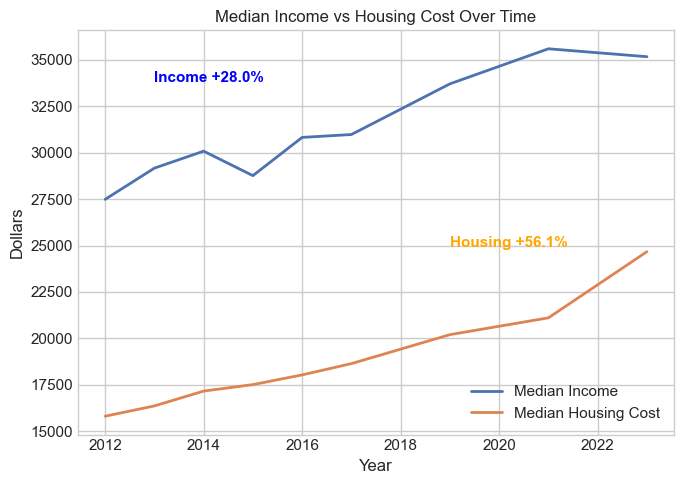

In [9]:
# Compute start/end values
start_year = df_yearly["year"].min()
end_year   = df_yearly["year"].max()

income_start = df_yearly.loc[df_yearly["year"] == start_year, "median_income"].values[0]
income_end   = df_yearly.loc[df_yearly["year"] == end_year, "median_income"].values[0]

housing_start = df_yearly.loc[df_yearly["year"] == start_year, "median_housing_cost"].values[0]
housing_end   = df_yearly.loc[df_yearly["year"] == end_year, "median_housing_cost"].values[0]

income_pct_change = (income_end - income_start) / income_start * 100
housing_pct_change = (housing_end - housing_start) / housing_start * 100


# Plot
plt.figure(figsize=(7, 5), dpi=100)
plt.plot(df_yearly["year"], df_yearly["median_income"], label="Median Income", linewidth=2)
plt.plot(df_yearly["year"], df_yearly["median_housing_cost"], label="Median Housing Cost", linewidth=2)

plt.xlabel("Year")
plt.ylabel("Dollars")
plt.title("Median Income vs Housing Cost Over Time")

# Add annotations
plt.text(
    df_yearly["year"].iloc[1],
    df_yearly["median_income"].max() * 0.95,
    f"Income +{income_pct_change:.1f}%",
    color="blue",
    fontsize=11,
    fontweight="bold"
)

plt.text(

    df_yearly["year"].iloc[-3],
    df_yearly["median_housing_cost"].iloc[-1] * 1.01,
    f"Housing +{housing_pct_change:.1f}%",
    color="orange",
    fontsize=11,
    fontweight="bold"

)

plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Make sure year is numeric
income_clean["year"] = pd.to_numeric(income_clean["year"])
housing_clean["year"] = pd.to_numeric(housing_clean["year"])

# Collapse to ONE value per year (mean is fine if there are duplicates)
income_yearly = income_clean.groupby("year", as_index=False)["median_income"].mean()
housing_yearly = housing_clean.groupby("year", as_index=False)["median_housing_cost"].mean()

# Merge and sort
df_yearly = income_yearly.merge(housing_yearly, on="year", how="inner").sort_values("year")

# Create gap metric(s)
df_yearly["income_housing_gap"] = df_yearly["median_income"] - df_yearly["median_housing_cost"]
df_yearly["housing_cost_ratio"] = df_yearly["median_housing_cost"] / df_yearly["median_income"]

df_yearly.head()





,year,median_income,median_housing_cost,income_housing_gap,housing_cost_ratio
0,2012,27488.888889,15807.0,11681.888889,0.575032
1,2013,29170.370370,16361.0,12809.370370,0.560877
2,2014,30085.185185,17160.0,12925.185185,0.570380
3,2015,28766.666667,17509.0,11257.666667,0.608656
4,2016,30825.925926,18032.0,12793.925926,0.584962


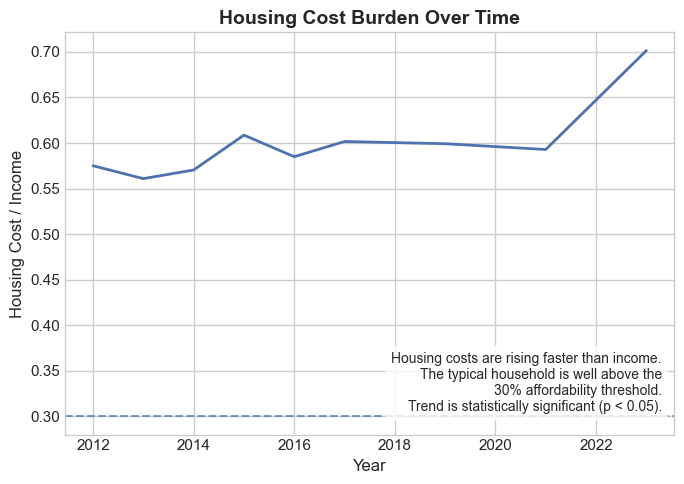

In [11]:

# Plot housing cost ratio over time

plt.figure(figsize=(7, 5), dpi=100)
plt.plot(df_yearly["year"], df_yearly["housing_cost_ratio"], linewidth=2)
plt.axhline(0.3, linestyle="--", alpha=0.7)

plt.title("Housing Cost Burden Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Housing Cost / Income")
plt.tight_layout()

summary_text = (
    "Housing costs are rising faster than income.\n"
    "The typical household is well above the\n"
    "30% affordability threshold.\n"
    "Trend is statistically significant (p < 0.05)."
)

plt.text(
    0.98, 0.05, summary_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="right",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)

plt.show()


In [12]:

# Statistical significance test
from scipy.stats import linregress

slope, _, _, p_value, _ = linregress(
    df_yearly["year"],
    df_yearly["housing_cost_ratio"]
)

print("Slope:", slope)
print("p-value:", p_value)


Slope: 0.008587389070576743
p-value: 0.015134541673265034
